# Validate ARC-AGI-2 Solutions

Loads ARC-AGI-2 training tasks and verifies every solver on all train and test pairs.

- `our_task_solutions.py` — our contribution (manually written solvers)
- `barc_task_solutions.py` — converted [BARC seed](https://github.com/xu3kev/BARC/tree/master/seeds) programs
- `llm_task_solutions.py` — additional solvers inferred from remaining training tasks

Clone the dataset first (from the repository root):

```bash
git clone https://github.com/arcprize/ARC-AGI-2.git
```

In [1]:
%matplotlib inline
import glob
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

import barc_task_solutions
import llm_task_solutions
import our_task_solutions

sys.setrecursionlimit(20000)

REPO_DIR = Path.cwd()
DATASET_DIR = REPO_DIR / "ARC-AGI-2"


In [2]:
def load_training_tasks(dataset_dir, split="training"):
    tasks = {}
    for path in glob.glob(str(Path(dataset_dir) / "data" / split / "*.json")):
        with open(path) as f:
            tasks[Path(path).stem] = json.load(f)
    return tasks


def list_solved_task_ids(solutions_path):
    return re.findall(r"^def solve_(\w+)\(", Path(solutions_path).read_text(), re.MULTILINE)


def validate_module(module, task_ids):
    train_ok, test_ok = [], []
    for i, task_id in enumerate(task_ids):
        task = tasks[task_id]
        solve_fn = getattr(module, f"solve_{task_id}")
        passed_train = our_task_solutions.verify_solution_outputs(task, "train", solve_fn)
        passed_test = our_task_solutions.verify_solution_outputs(task, "test", solve_fn)
        train_ok.append(passed_train)
        test_ok.append(passed_test)
        status = "PASS" if passed_train and passed_test else "FAIL"
        print(f"({i + 1:3d}/{len(task_ids)}) {task_id}  {status}  train={passed_train}  test={passed_test}")
    failed = [tid for tid, tr, te in zip(task_ids, train_ok, test_ok) if not (tr and te)]
    if failed:
        print("Failed:", ", ".join(failed))
    else:
        print(f"\nAll {len(task_ids)} solutions validated successfully.")
    assert not failed, f"{len(failed)}/{len(task_ids)} functions failed"


if not (DATASET_DIR / "data" / "training").is_dir():
    raise FileNotFoundError(
        f"ARC-AGI-2 dataset not found at {DATASET_DIR}\n"
        "Clone it from the repository root:\n"
        "  git clone https://github.com/arcprize/ARC-AGI-2.git"
    )

tasks = load_training_tasks(DATASET_DIR)
print(f"Loaded {len(tasks)} training tasks.")

Loaded 1000 training tasks.


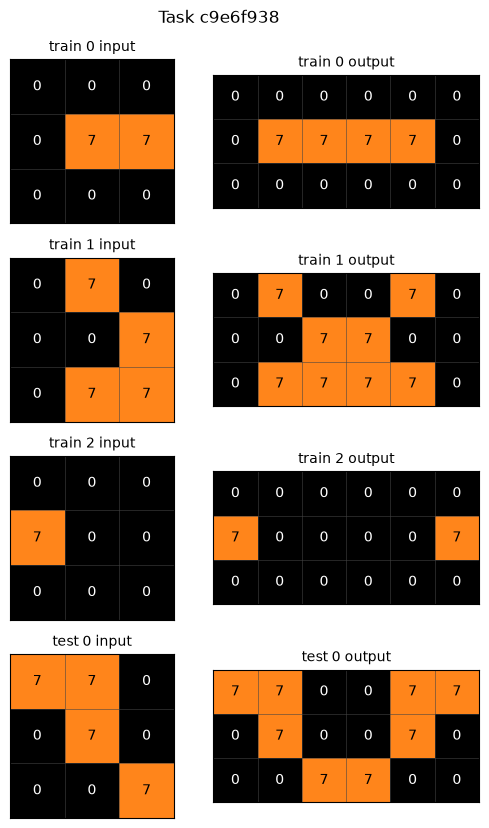

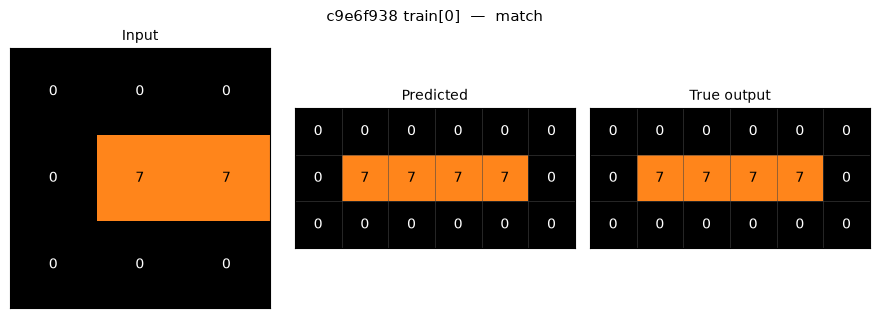

True

In [3]:
# Official ARC-AGI colors 0–9.
ARC_COLORS = [
    "#000000",  # 0 black
    "#0074D9",  # 1 blue
    "#FF4136",  # 2 red
    "#2ECC40",  # 3 green
    "#FFDC00",  # 4 yellow
    "#AAAAAA",  # 5 grey
    "#F012BE",  # 6 magenta
    "#FF851B",  # 7 orange
    "#7FDBFF",  # 8 cyan
    "#870C25",  # 9 maroon
]
ARC_CMAP = ListedColormap(ARC_COLORS)
_LIGHT = {4, 5, 7, 8}


def plot_grid(grid, title="", ax=None):
    grid = np.asarray(grid)
    ax = ax or plt.gca()
    ax.imshow(grid, cmap=ARC_CMAP, vmin=0, vmax=9, interpolation="nearest")
    ax.set_xticks(np.arange(grid.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(grid.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="#444444", linewidth=0.4)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=10)

    fontsize = max(5, min(10, 90 // max(grid.shape)))
    for i, j in np.ndindex(grid.shape):
        val = int(grid[i, j])
        ax.text(
            j, i, str(val), ha="center", va="center",
            color="black" if val in _LIGHT else "white", fontsize=fontsize,
        )


def show_arc_task(task, task_id=""):
    rows = [(f"train {i}", pair) for i, pair in enumerate(task["train"])]
    rows += [(f"test {i}", pair) for i, pair in enumerate(task["test"])]
    fig, axes = plt.subplots(len(rows), 2, figsize=(5.5, 2.1 * len(rows)), squeeze=False)
    if task_id:
        fig.suptitle(f"Task {task_id}", fontsize=12)
    for r, (label, pair) in enumerate(rows):
        plot_grid(pair["input"], f"{label} input", axes[r, 0])
        plot_grid(pair["output"], f"{label} output", axes[r, 1])
    plt.tight_layout()
    plt.show()


def show_comparison(input_grid, predicted, true_output, title=""):
    input_grid = np.asarray(input_grid)
    predicted = np.asarray(predicted)
    true_output = np.asarray(true_output)
    match = predicted.shape == true_output.shape and np.array_equal(predicted, true_output)

    fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
    plot_grid(input_grid, "Input", axes[0])
    plot_grid(predicted, "Predicted" if match else "Predicted (mismatch)", axes[1])
    plot_grid(true_output, "True output", axes[2])

    if not match and predicted.shape == true_output.shape:
        for i, j in zip(*np.where(predicted != true_output)):
            axes[1].add_patch(
                plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="white", linewidth=1.6)
            )

    if title:
        fig.suptitle(f"{title}  —  {'match' if match else 'mismatch'}", fontsize=11)
    plt.tight_layout()
    plt.show()
    return match


task_id = "c9e6f938"
task = tasks[task_id]
solve_fn = getattr(our_task_solutions, f"solve_{task_id}")

show_arc_task(task, task_id)

pair = task["train"][0]
predicted = solve_fn(pair["input"])
show_comparison(pair["input"], predicted, pair["output"], title=f"{task_id} train[0]")


## Our solutions (`our_task_solutions.py`)

Manually written solvers contributed in this repository.

In [4]:
our_ids = list_solved_task_ids(REPO_DIR / "our_task_solutions.py")
print(f"Found {len(our_ids)} solution functions in our_task_solutions.py")
validate_module(our_task_solutions, our_ids)

Found 222 solution functions in our_task_solutions.py
(  1/222) c9e6f938  PASS  train=True  test=True
(  2/222) 0520fde7  PASS  train=True  test=True
(  3/222) c8f0f002  PASS  train=True  test=True
(  4/222) b1948b0a  PASS  train=True  test=True
(  5/222) 3618c87e  PASS  train=True  test=True
(  6/222) a79310a0  PASS  train=True  test=True
(  7/222) be03b35f  PASS  train=True  test=True
(  8/222) 8be77c9e  PASS  train=True  test=True
(  9/222) a85d4709  PASS  train=True  test=True
( 10/222) 44f52bb0  PASS  train=True  test=True
( 11/222) 94f9d214  PASS  train=True  test=True
( 12/222) bdad9b1f  PASS  train=True  test=True
( 13/222) 25ff71a9  PASS  train=True  test=True
( 14/222) 99b1bc43  PASS  train=True  test=True
( 15/222) 017c7c7b  PASS  train=True  test=True
( 16/222) 49d1d64f  PASS  train=True  test=True
( 17/222) ed36ccf7  PASS  train=True  test=True
( 18/222) aedd82e4  PASS  train=True  test=True
( 19/222) e9afcf9a  PASS  train=True  test=True
( 20/222) 6430c8c4  PASS  train=Tr

## BARC seed solutions (`barc_task_solutions.py`)

Converted programs from [BARC/seeds](https://github.com/xu3kev/BARC/tree/master/seeds). Seeds that use BARC `[x, y]` indexing are wrapped with `_barc_xy` (transpose to ARC `[row, col]`).

In [5]:
barc_ids = list_solved_task_ids(REPO_DIR / "barc_task_solutions.py")
print(f"Found {len(barc_ids)} solution functions in barc_task_solutions.py")
validate_module(barc_task_solutions, barc_ids)

Found 158 solution functions in barc_task_solutions.py
(  1/158) 007bbfb7  PASS  train=True  test=True


(  2/158) 00d62c1b  PASS  train=True  test=True
(  3/158) 017c7c7b  PASS  train=True  test=True
(  4/158) 025d127b  PASS  train=True  test=True


(  5/158) 045e512c  PASS  train=True  test=True
(  6/158) 0520fde7  PASS  train=True  test=True
(  7/158) 05269061  PASS  train=True  test=True
(  8/158) 05f2a901  PASS  train=True  test=True
(  9/158) 06df4c85  PASS  train=True  test=True
( 10/158) 08ed6ac7  PASS  train=True  test=True
( 11/158) 09629e4f  PASS  train=True  test=True
( 12/158) 0962bcdd  PASS  train=True  test=True
( 13/158) 0a938d79  PASS  train=True  test=True
( 14/158) 0b148d64  PASS  train=True  test=True
( 15/158) 0ca9ddb6  PASS  train=True  test=True
( 16/158) 0d3d703e  PASS  train=True  test=True
( 17/158) 0e206a2e  PASS  train=True  test=True
( 18/158) 10fcaaa3  PASS  train=True  test=True
( 19/158) 11852cab  PASS  train=True  test=True
( 20/158) 1190e5a7  PASS  train=True  test=True
( 21/158) 137eaa0f  PASS  train=True  test=True
( 22/158) 150deff5  PASS  train=True  test=True
( 23/158) 178fcbfb  PASS  train=True  test=True


( 24/158) 1a07d186  PASS  train=True  test=True
( 25/158) 1b2d62fb  PASS  train=True  test=True
( 26/158) 1b60fb0c  PASS  train=True  test=True
( 27/158) 1bfc4729  PASS  train=True  test=True
( 28/158) 1caeab9d  PASS  train=True  test=True
( 29/158) 1cf80156  PASS  train=True  test=True
( 30/158) 1e32b0e9  PASS  train=True  test=True
( 31/158) 1f642eb9  PASS  train=True  test=True
( 32/158) 1fad071e  PASS  train=True  test=True
( 33/158) 2204b7a8  PASS  train=True  test=True
( 34/158) 228f6490  PASS  train=True  test=True
( 35/158) 23581191  PASS  train=True  test=True
( 36/158) 239be575  PASS  train=True  test=True
( 37/158) 25d487eb  PASS  train=True  test=True
( 38/158) 25d8a9c8  PASS  train=True  test=True
( 39/158) 25ff71a9  PASS  train=True  test=True
( 40/158) 264363fd  PASS  train=True  test=True
( 41/158) 28e73c20  PASS  train=True  test=True
( 42/158) 29623171  PASS  train=True  test=True
( 43/158) 29c11459  PASS  train=True  test=True
( 44/158) 2bcee788  PASS  train=True  te

( 57/158) 3eda0437  PASS  train=True  test=True
( 58/158) 3f7978a0  PASS  train=True  test=True
( 59/158) 4093f84a  PASS  train=True  test=True
( 60/158) 41e4d17e  PASS  train=True  test=True
( 61/158) 4258a5f9  PASS  train=True  test=True
( 62/158) 444801d8  PASS  train=True  test=True
( 63/158) 44d8ac46  PASS  train=True  test=True
( 64/158) 44f52bb0  PASS  train=True  test=True
( 65/158) 469497ad  PASS  train=True  test=True
( 66/158) 46f33fce  PASS  train=True  test=True
( 67/158) 48d8fb45  PASS  train=True  test=True


( 68/158) 4c5c2cf0  PASS  train=True  test=True
( 69/158) 508bd3b6  PASS  train=True  test=True
( 70/158) 5168d44c  PASS  train=True  test=True
( 71/158) 54d82841  PASS  train=True  test=True
( 72/158) 56dc2b01  PASS  train=True  test=True
( 73/158) 57aa92db  PASS  train=True  test=True
( 74/158) 5c2c9af4  PASS  train=True  test=True
( 75/158) 5daaa586  PASS  train=True  test=True
( 76/158) 623ea044  PASS  train=True  test=True
( 77/158) 6455b5f5  PASS  train=True  test=True
( 78/158) 681b3aeb  PASS  train=True  test=True
( 79/158) 6855a6e4  PASS  train=True  test=True
( 80/158) 6a1e5592  PASS  train=True  test=True


( 81/158) 6aa20dc0  PASS  train=True  test=True
( 82/158) 6b9890af  PASS  train=True  test=True
( 83/158) 6cdd2623  PASS  train=True  test=True
( 84/158) 6cf79266  PASS  train=True  test=True
( 85/158) 6d58a25d  PASS  train=True  test=True
( 86/158) 6d75e8bb  PASS  train=True  test=True
( 87/158) 6e19193c  PASS  train=True  test=True
( 88/158) 6e82a1ae  PASS  train=True  test=True
( 89/158) 6ecd11f4  PASS  train=True  test=True
( 90/158) 6f8cd79b  PASS  train=True  test=True
( 91/158) 6fa7a44f  PASS  train=True  test=True
( 92/158) 72ca375d  PASS  train=True  test=True
( 93/158) 7447852a  PASS  train=True  test=True
( 94/158) 746b3537  PASS  train=True  test=True
( 95/158) 776ffc46  PASS  train=True  test=True
( 96/158) 780d0b14  PASS  train=True  test=True
( 97/158) 7837ac64  PASS  train=True  test=True
( 98/158) 7c008303  PASS  train=True  test=True
( 99/158) 7e0986d6  PASS  train=True  test=True
(100/158) 7f4411dc  PASS  train=True  test=True
(101/158) 810b9b61  PASS  train=True  te

(111/158) 97a05b5b  PASS  train=True  test=True
(112/158) 995c5fa3  PASS  train=True  test=True
(113/158) 9af7a82c  PASS  train=True  test=True
(114/158) 9f236235  PASS  train=True  test=True
(115/158) a78176bb  PASS  train=True  test=True
(116/158) a79310a0  PASS  train=True  test=True
(117/158) a8c38be5  PASS  train=True  test=True
(118/158) a9f96cdd  PASS  train=True  test=True
(119/158) aabf363d  PASS  train=True  test=True
(120/158) aba27056  PASS  train=True  test=True
(121/158) aedd82e4  PASS  train=True  test=True
(122/158) af902bf9  PASS  train=True  test=True
(123/158) b527c5c6  PASS  train=True  test=True
(124/158) b7249182  PASS  train=True  test=True
(125/158) b775ac94  PASS  train=True  test=True
(126/158) b782dc8a  PASS  train=True  test=True
(127/158) bbc9ae5d  PASS  train=True  test=True
(128/158) bc1d5164  PASS  train=True  test=True
(129/158) bd4472b8  PASS  train=True  test=True
(130/158) caa06a1f  PASS  train=True  test=True
(131/158) ce602527  PASS  train=True  te

(157/158) feca6190  PASS  train=True  test=True
(158/158) ff28f65a  PASS  train=True  test=True

All 158 solutions validated successfully.


## LLM-assisted solutions (`llm_task_solutions.py`)

Solvers for remaining training tasks. Each function is included only if it matches every official train and test pair.

In [6]:
llm_ids = list_solved_task_ids(REPO_DIR / "llm_task_solutions.py")
print(f"Found {len(llm_ids)} solution functions in llm_task_solutions.py")
validate_module(llm_task_solutions, llm_ids)

Found 37 solution functions in llm_task_solutions.py
(  1/37) 00576224  PASS  train=True  test=True
(  2/37) 0692e18c  PASS  train=True  test=True
(  3/37) 0c786b71  PASS  train=True  test=True
(  4/37) 15696249  PASS  train=True  test=True
(  5/37) 1a2e2828  PASS  train=True  test=True
(  6/37) 1e0a9b12  PASS  train=True  test=True
(  7/37) 1f85a75f  PASS  train=True  test=True
(  8/37) 22168020  PASS  train=True  test=True
(  9/37) 23b5c85d  PASS  train=True  test=True
( 10/37) 27a28665  PASS  train=True  test=True
( 11/37) 34b99a2b  PASS  train=True  test=True
( 12/37) 3906de3d  PASS  train=True  test=True
( 13/37) 3af2c5a8  PASS  train=True  test=True
( 14/37) 3c9b0459  PASS  train=True  test=True
( 15/37) 496994bd  PASS  train=True  test=True
( 16/37) 5582e5ca  PASS  train=True  test=True
( 17/37) 60c09cac  PASS  train=True  test=True
( 18/37) 662c240a  PASS  train=True  test=True
( 19/37) 67a3c6ac  PASS  train=True  test=True
( 20/37) 68b67ca3  PASS  train=True  test=True
( 21/37